<a href="https://colab.research.google.com/github/shivampatle2004/Machine-Learning-/blob/main/K_Nearest_Neighbors_(KNN)_shivam_cs23186.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

K-Nearest Neighbors (KNN)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### Model Training
We will now initialize the `KNeighborsClassifier` with our chosen value of K and fit it to the scaled training data.

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

if 'X_train_scaled' in globals() and 'y_train' in globals():
    # Initialize the KNN classifier
    knn = KNeighborsClassifier(n_neighbors=K)

    # Train the model
    knn.fit(X_train_scaled, y_train)

    print(f"KNN model trained with K={K}")

    # Make predictions on the test set
    y_pred = knn.predict(X_test_scaled)

    # Evaluation metrics
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))
    print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
else:
    print("Error: Scaled training data not found. Please ensure the scaling cell (947c7441) runs successfully first.")

Error: Scaled training data not found. Please ensure the scaling cell (947c7441) runs successfully first.


In [11]:
from google.colab import drive
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Mount Drive
drive.mount('/content/drive', force_remount=True)

# 2. Define Path and Load Data
path = '/content/drive/MyDrive/ml_dataset/BreastCancer.csv'
df = pd.read_csv(path)
print('Dataset loaded successfully.')

# 3. Clean Data and Separate Features and Target
# Drop 'id' (not a feature) and 'Unnamed: 32' (all NaNs)
# 'diagnosis' is our target, so it must be removed from X
X = df.drop(columns=['id', 'diagnosis', 'Unnamed: 32'], errors='ignore')
y = df['diagnosis']

# 4. Split and Scale
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5. Define K
K = 5

print('Data pipeline completed successfully with cleaned features.')
print(f'Features being used: {list(X.columns)}')

Mounted at /content/drive
Dataset loaded successfully.
Data pipeline completed successfully with cleaned features.
Features being used: ['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [12]:
path="/content/drive/MyDrive/ml_dataset/BreastCancer.csv"
df = pd.read_csv(path)
import pandas as pd

In [13]:
# Let's define a value for K. We'll start with a common heuristic.
# For example, if you have a dataset with 'n_samples' data points, a common starting point for K is sqrt(n_samples).

# We don't have a DataFrame loaded yet, so let's pick a default value for now.
# Once data is loaded, we can refine this.
K = 5 # A commonly used starting value for K
print(f"Initial K value set to: {K}")

Initial K value set to: 5


In [14]:
import pandas as pd

# Load the dataset using the defined path
try:
    df = pd.read_csv(path)
    print("Dataset loaded successfully.")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file was not found at {path}. Please ensure the path is correct and Google Drive is mounted.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

Dataset loaded successfully.


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [15]:
if 'df' in globals():
    # Check for missing values and data types
    print(df.info())
    print("\nMissing values per column:")
    print(df.isnull().sum())

    # Display summary statistics
    display(df.describe())
else:
    print("Error: 'df' is not defined. Please run the cell above (09b04cf9) that loads the dataset first.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


Before applying KNN, we need to separate the features (X) from the target (y). For the Breast Cancer dataset, the goal is typically to predict the 'diagnosis' or 'class'.

In [16]:
if 'df' in globals():
    # Assuming the last column is the target and the rest are features
    # Adjust these indices if the dataset structure is different
    X = df.iloc[:, :-1]
    y = df.iloc[:, -1]

    print(f"Features shape: {X.shape}")
    print(f"Target shape: {y.shape}")
else:
    print("Error: 'df' is not defined. Please ensure the dataset loading cell (09b04cf9) has been executed successfully.")

Features shape: (569, 32)
Target shape: (569,)


### Feature Scaling and Data Splitting
We will use `StandardScaler` to normalize our features and `train_test_split` to create sets for training and evaluation.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Ensure we are using the cleaned version of X (dropping non-numeric columns)
if 'df' in globals():
    # Drop non-numeric and target columns to prevent the 'B'/'M' float conversion error
    X_clean = df.drop(columns=['id', 'diagnosis', 'Unnamed: 32'], errors='ignore')
    y_clean = df['diagnosis']

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

    # Initialize and apply scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print("Data split and scaling completed successfully.")
    print(f"Processed {X_train_scaled.shape[1]} numeric features.")
else:
    print("Error: DataFrame 'df' not found. Please run cell 09b04cf9 first.")

Data split and scaling completed successfully.
Processed 30 numeric features.


### Target Variable Distribution
Let's visualize the frequency of each class in the `diagnosis` column.

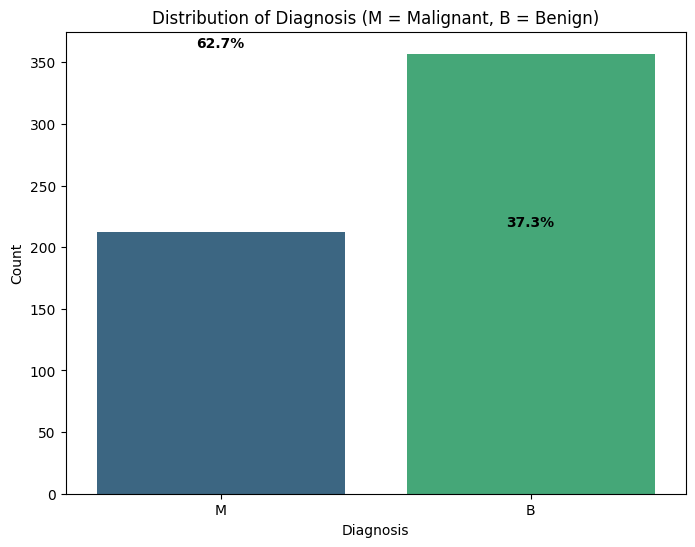

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'df' in globals():
    plt.figure(figsize=(8, 6))
    # Updated to assign x to hue to avoid FutureWarning
    sns.countplot(x='diagnosis', data=df, hue='diagnosis', palette='viridis', legend=False)
    plt.title('Distribution of Diagnosis (M = Malignant, B = Benign)')
    plt.xlabel('Diagnosis')
    plt.ylabel('Count')

    # Calculate percentages
    counts = df['diagnosis'].value_counts()
    for i, count in enumerate(counts):
        percentage = (count / len(df)) * 100
        plt.text(i, count + 5, f'{percentage:.1f}%', ha='center', fontweight='bold')

    plt.show()
else:
    print("Error: DataFrame 'df' not found. Please load the data first.")

In [23]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize and train the model
knn = KNeighborsClassifier(n_neighbors=K)
knn.fit(X_train_scaled, y_train)

# Make predictions
y_pred = knn.predict(X_test_scaled)

# Display results
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print(f"\nAccuracy Score: {accuracy_score(y_test, y_pred):.4f}")

Confusion Matrix:
[[68  3]
 [ 3 40]]

Classification Report:
              precision    recall  f1-score   support

           B       0.96      0.96      0.96        71
           M       0.93      0.93      0.93        43

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114


Accuracy Score: 0.9474
